In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB,BernoulliNB
from sklearn.metrics import(accuracy_score,precision_score, recall_score, f1_score)

In [10]:
train_data = fetch_20newsgroups(subset="test", remove=("headers","footers","quotes"))
test_data = fetch_20newsgroups(subset="test", remove=("headers","footers","quotes"))
x_train_text = train_data.data
y_train = train_data.target
x_test_text = test_data.data
y_test = test_data.target
class_names = train_data.target_names
print("training Documents :" , len(x_train_text))
print("Testing Documents :" , len(x_test_text))
print("Number of classes:" , len(class_names))
      

training Documents : 7532
Testing Documents : 7532
Number of classes: 20


In [16]:
vectorizer = CountVectorizer(stop_words="english",min_df=2)
x_train = vectorizer.fit_transform(x_train_text)
x_test = vectorizer.transform(x_test_text)

print("training feature matrix:", x_train.shape)
print("testing feature matrix:", x_test.shape)

mnb = MultinomialNB()
mnb.fit(x_train,y_train)
y_pred_mnb= mnb.predict(x_test)

binary_vectorizer = CountVectorizer(stop_words="english",min_df=2,binary=True)

x_train_binary = binary_vectorizer.fit_transform(x_train_text)
x_test_binary = binary_vectorizer.transform(x_test_text)

training feature matrix: (7532, 27818)
testing feature matrix: (7532, 27818)


In [18]:
bnb = BernoulliNB()
bnb.fit(x_train_binary,y_train)
y_pred_bnb=bnb.predict(x_test_binary)

results = pd.DataFrame({
    "model": [
        "Multinomial NB",
        "Bernoulli NB"
    ],
    
    "Accuracy": [
        accuracy_score(y_test, y_pred_mnb),
        accuracy_score(y_test, y_pred_bnb)
    ],
    
    "Precision": [
        precision_score(y_test, y_pred_mnb, average="macro"),
        precision_score(y_test, y_pred_bnb, average="macro")
    ],
    
    "Recall": [
        recall_score(y_test, y_pred_mnb, average="macro"),
        recall_score(y_test, y_pred_bnb, average="macro")
    ],
    
    "F1-Score": [
        f1_score(y_test, y_pred_mnb, average="macro"),
        f1_score(y_test, y_pred_bnb, average="macro")
    ]
})

print(results)

            model  Accuracy  Precision    Recall  F1-Score
0  Multinomial NB  0.857674   0.872156  0.852714  0.856162
1    Bernoulli NB  0.641529   0.854278  0.626395  0.669906


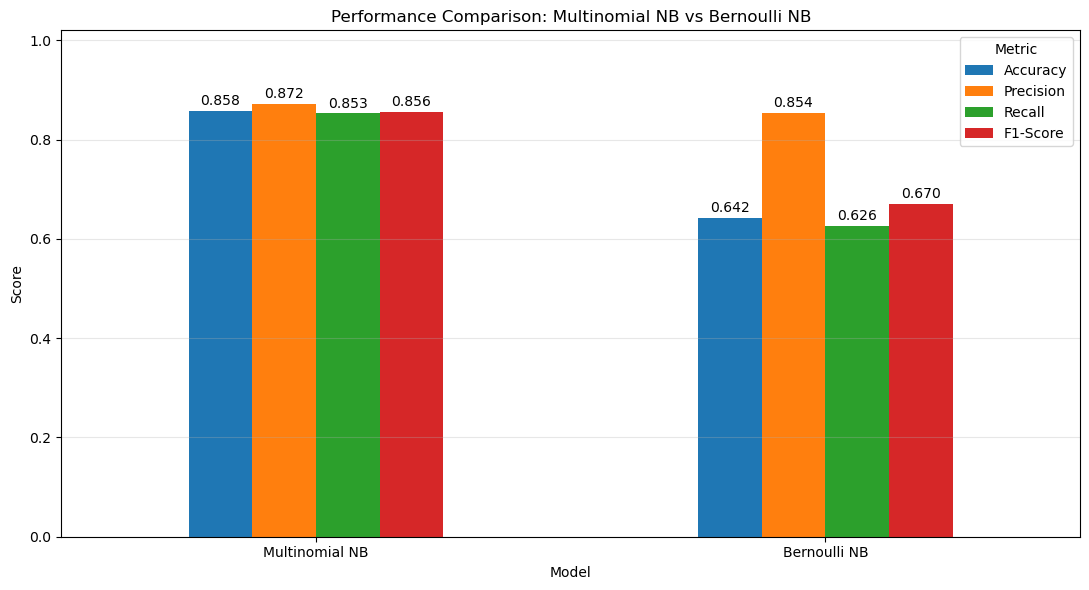

In [27]:
results_metrics = results[["model", "Accuracy", "Precision", "Recall", "F1-Score"]]

ax = results_metrics.set_index("model").plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Performance Comparison: Multinomial NB vs Bernoulli NB")
plt.xlabel("Model")
plt.ylabel("Score")

plt.ylim(0, 1.02)

plt.xticks(rotation=0)
plt.legend(title="Metric")

plt.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=2
    )

plt.tight_layout()
plt.show()